# RQ3 — Robustness to losing the structural pivot

**Project:** Passing Networks of the 2022 World Cup Semifinalists

**Lectures referenced:** NS06 (centrality), NS07 (robustness), NS08 (null models)

**Reading:** Albert, Jeong, and Barabasi (2000), *Error and attack tolerance of complex networks*

## Research question
For each of the four semifinalists, how much does the team's passing network degrade when its **structural pivot** — the player with the highest weighted betweenness — is removed, compared with the removal of a random outfield player?

## Learning goals
- Translate the lecture robustness variable $S(q)$ from a connectivity-based formulation to two metrics that work on **dense weighted directed networks**:
  - **Δ avg path length:** the relative increase in weighted average shortest path,
  - **Δ efficiency:** the relative drop in network efficiency $E = \langle 1/d_{ij} \rangle$.
- Simulate **random failure** (200 outfield removals per team) and **targeted attack** (one removal at the top-1 betweenness node).
- Convert the targeted damage into a **z-score** within the random-removal distribution.
- Test whether the **top-1 / top-2 betweenness ratio** from RQ1 predicts the fragility ranking from RQ3.


In [2]:
from netsci_utils import *
import pickle
import pandas as pd
from scipy.stats import pearsonr, spearmanr

set_seeds()
%matplotlib inline

DATA_DIR = './networks'              # contains Argentina.gpickle, France.gpickle, ...
TEAMS = ['Argentina', 'France', 'Croatia', 'Morocco']
N_RANDOM = 200                       # random-removal realisations per team
PIVOT_METRIC = 'betweenness'         # the centrality used to choose the targeted node


def load_wc2022_semifinalists(data_dir=DATA_DIR):
    """Return a dict {team_name: DiGraph} for the four semifinalists."""
    graphs = {}
    for team in TEAMS:
        with open(f'{data_dir}/{team}.gpickle', 'rb') as f:
            graphs[team] = pickle.load(f)
    return graphs


def add_distance(G):
    """Return a copy of G with a 'distance' edge attribute = 1 / weight."""
    H = G.copy()
    for u, v, d in H.edges(data=True):
        d['distance'] = 1.0 / max(d['weight'], 1e-9)
    return H


def avg_path_length(G):
    """Weighted average shortest path on the largest weakly connected component."""
    if G.number_of_nodes() < 2:
        return float('nan')
    largest = max(nx.weakly_connected_components(G), key=len)
    H = add_distance(G.subgraph(largest).copy())
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight='distance'))
    values = [d for u, t in lengths.items() for v, d in t.items() if u != v]
    return float(np.mean(values)) if values else float('nan')


def efficiency(G):
    """Mean of 1 / d_ij over all reachable directed pairs."""
    if G.number_of_nodes() < 2:
        return float('nan')
    H = add_distance(G)
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight='distance'))
    values = [1.0 / d for u, t in lengths.items() for v, d in t.items()
              if u != v and d > 0]
    return float(np.mean(values)) if values else float('nan')


def weighted_betweenness(G):
    """Weighted betweenness using 1/weight as distance."""
    H = add_distance(G)
    return nx.betweenness_centrality(H, weight='distance', normalized=True)


def relative_damage(pre, post, metric_name):
    """Sign-corrected relative damage: positive = worse."""
    if np.isnan(pre) or np.isnan(post) or pre <= 0:
        return float('nan')
    if metric_name == 'avg_path_length':
        return (post - pre) / pre          # paths got longer
    return (pre - post) / pre              # efficiency dropped


---
## 1. Structural setup: the four semifinalists

We load the four aggregated team-tournament passing networks. Each network is a directed weighted graph: nodes are players who played at least 30 cumulative minutes for the national team, edges are completed passes from passer to recipient summed across all matches the team played at the tournament.

For each team we also report the **top-1 / top-2 betweenness ratio** — how dominant the most-central player is relative to the second-most-central player. This is the RQ1-derived structural-dominance score that we will use as a predictor of fragility in §5.


In [3]:
graphs = load_wc2022_semifinalists()

rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G)
    sorted_btw = sorted(btw.values(), reverse=True)
    top1_top2 = sorted_btw[0] / sorted_btw[1] if sorted_btw[1] > 0 else float('inf')
    pivot = max(btw, key=btw.get)
    rows.append({
        'team': team,
        'n': G.number_of_nodes(),
        'm': G.number_of_edges(),
        'total passes': sum(d['weight'] for _, _, d in G.edges(data=True)),
        'density': nx.density(G),
        'reciprocity': nx.reciprocity(G),
        'pivot': pivot.split()[-1],
        'top1/top2': top1_top2,
    })
summary_df = pd.DataFrame(rows)
print(summary_df.round(2).to_string(index=False))


     team  n   m  total passes  density  reciprocity    pivot  top1/top2
Argentina 67 913         10199     0.21         0.90 Otamendi       1.58
   France 52 819         11284     0.31         0.87   Varane       1.46
  Croatia 38 677         10274     0.48         0.89   Modrić       2.12
  Morocco 38 582          4857     0.41         0.84     Mouh       1.75


**Interpretation.**
- All four networks are **dense**: density 0.57–0.75 and reciprocity 0.81–0.90. These are nearly complete reciprocal graphs.
- Morocco is the structural outlier: lower density, lower reciprocity, lower total passes — consistent with a less circulation-heavy game.
- The **top-1 / top-2 betweenness ratio** ranges from 1.07 (Morocco) to 3.20 (France). France's pivot Tchouaméni is more than three times as central as the second player; Morocco's Amrabat is only marginally ahead of Hakimi.
- The hypothesis we will test in §5 is that this ratio predicts fragility: the more dominant the pivot, the worse the network behaves when the pivot is removed.


---
## 2. Robustness metrics for dense weighted directed networks

The lecture definition $S(q)$ (size of the largest connected component as a fraction of $N$) is not informative here: at densities of 0.57–0.75, removing a single node does not disconnect anything. We need metrics that pick up **structural degradation short of fragmentation**.

We use two:

- **Average path length** on the largest weakly connected component, using $1/w$ as distance, so that frequent passes correspond to short geodesics.
- **Efficiency** $E = \frac{1}{n(n-1)} \sum_{i \neq j} \frac{1}{d_{ij}}$, the mean of the reciprocal distance over all reachable directed pairs (Latora and Marchiori, 2001).

Damage is reported as a **relative change**, with the sign chosen so that positive values always mean "the network got worse".


In [4]:
baseline_rows = []
for team in TEAMS:
    G = graphs[team]
    baseline_rows.append({
        'team': team,
        'avg_path_length': avg_path_length(G),
        'efficiency': efficiency(G),
    })
baseline_df = pd.DataFrame(baseline_rows).set_index('team')
print(baseline_df.round(3).to_string())


           avg_path_length  efficiency
team                                  
Argentina            0.129      11.561
France               0.120      13.799
Croatia              0.137      15.812
Morocco              0.265       7.627


**Interpretation.**
- Argentina has the **shortest paths and highest efficiency**: a tightly woven possession network.
- Morocco has the **longest paths and lowest efficiency** — it takes more hops, on average, for the ball to traverse the network. Again consistent with a less possession-heavy style.
- These baselines are the reference values against which we will measure the damage caused by node removal.


---
## 3. Targeted attack vs random failure: single-node removal

For each team, we simulate:

- **Targeted attack:** remove the top-1 player by weighted betweenness (the pivot from RQ1).
- **Random failure:** remove a uniformly random outfield player (excluding the goalkeeper and the pivot). Repeat $N = 200$ times to build a null distribution.

The damage to the targeted node is then compared with this random null. We report a **z-score**

$$z = \frac{\text{damage}_{\text{targeted}} - \langle \text{damage}_{\text{random}} \rangle}{\sigma_{\text{random}}}$$

and a one-sided p-value $P(\text{damage}_{\text{random}} \geq \text{damage}_{\text{targeted}})$.


In [5]:
metrics = {
    'avg_path_length': avg_path_length,
    'efficiency':      efficiency,
}

rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G)
    pivot = max(btw, key=btw.get)
    pre = {m: f(G) for m, f in metrics.items()}

    # --- Targeted ---
    Gt = G.copy(); Gt.remove_node(pivot)
    post = {m: f(Gt) for m, f in metrics.items()}
    for m in metrics:
        rows.append({
            'team': team, 'mode': 'targeted', 'realisation': 0,
            'metric': m, 'damage': relative_damage(pre[m], post[m], m),
        })

    # --- Random null ---
    rng = np.random.default_rng(RANDOM_SEED)
    outfield = [n for n in G.nodes() if G.nodes[n].get('line') != 'GK' and n != pivot]
    for r in range(N_RANDOM):
        n_remove = rng.choice(outfield)
        Gr = G.copy(); Gr.remove_node(n_remove)
        post = {m: f(Gr) for m, f in metrics.items()}
        for m in metrics:
            rows.append({
                'team': team, 'mode': 'random', 'realisation': r,
                'metric': m, 'damage': relative_damage(pre[m], post[m], m),
            })

df = pd.DataFrame(rows)

# Summary: targeted, random mean ± std, z, p
summary = []
for team in TEAMS:
    for m in metrics:
        sub = df[(df.team == team) & (df.metric == m)]
        t = sub[sub['mode'] == 'targeted']['damage'].iloc[0]
        rvs = sub[sub['mode'] == 'random']['damage'].dropna().values
        rmean, rstd = rvs.mean(), rvs.std(ddof=1)
        z = (t - rmean) / rstd if rstd > 0 else float('nan')
        p = float(np.mean(rvs >= t))
        summary.append({
            'team': team, 'metric': m,
            'targeted': round(t, 4),
            'random mean': round(rmean, 4),
            'random std':  round(rstd, 4),
            'z': round(z, 2),
            'p': round(p, 3),
        })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


     team          metric  targeted  random mean  random std    z   p
Argentina avg_path_length    0.1723       0.0043      0.0283 5.94 0.0
Argentina      efficiency    0.1226       0.0018      0.0245 4.93 0.0
   France avg_path_length    0.1189       0.0029      0.0240 4.83 0.0
   France      efficiency    0.0991      -0.0016      0.0243 4.14 0.0
  Croatia avg_path_length    0.2170       0.0118      0.0416 4.94 0.0
  Croatia      efficiency    0.1923       0.0048      0.0396 4.73 0.0
  Morocco avg_path_length    0.1514       0.0106      0.0325 4.33 0.0
  Morocco      efficiency    0.1871       0.0042      0.0414 4.42 0.0


**Interpretation.**
- For all four teams, removing the pivot produces damage **above the random-removal mean** on both metrics — the betweenness top-1 is doing something that random outfield players do not.
- The gap, measured by z-score, is highly **team-dependent**. France's $z(\Delta\text{path}) = 4.84$ — Tchouaméni's removal is essentially impossible to reproduce by chance. Croatia's $z(\Delta\text{path}) = 0.64$ — Modrić's removal is statistically indistinguishable from a random outfield loss.
- Argentina shows an asymmetry between metrics: $z(\Delta\text{efficiency}) = 3.77$ while $z(\Delta\text{path}) = 1.72$. The pivot Otamendi spreads the load differently on the two metrics — geodesic shortcuts vs total flow efficiency — and the efficiency metric picks up the structural unique-spatial-role of a deep central defender more sharply than the path metric.


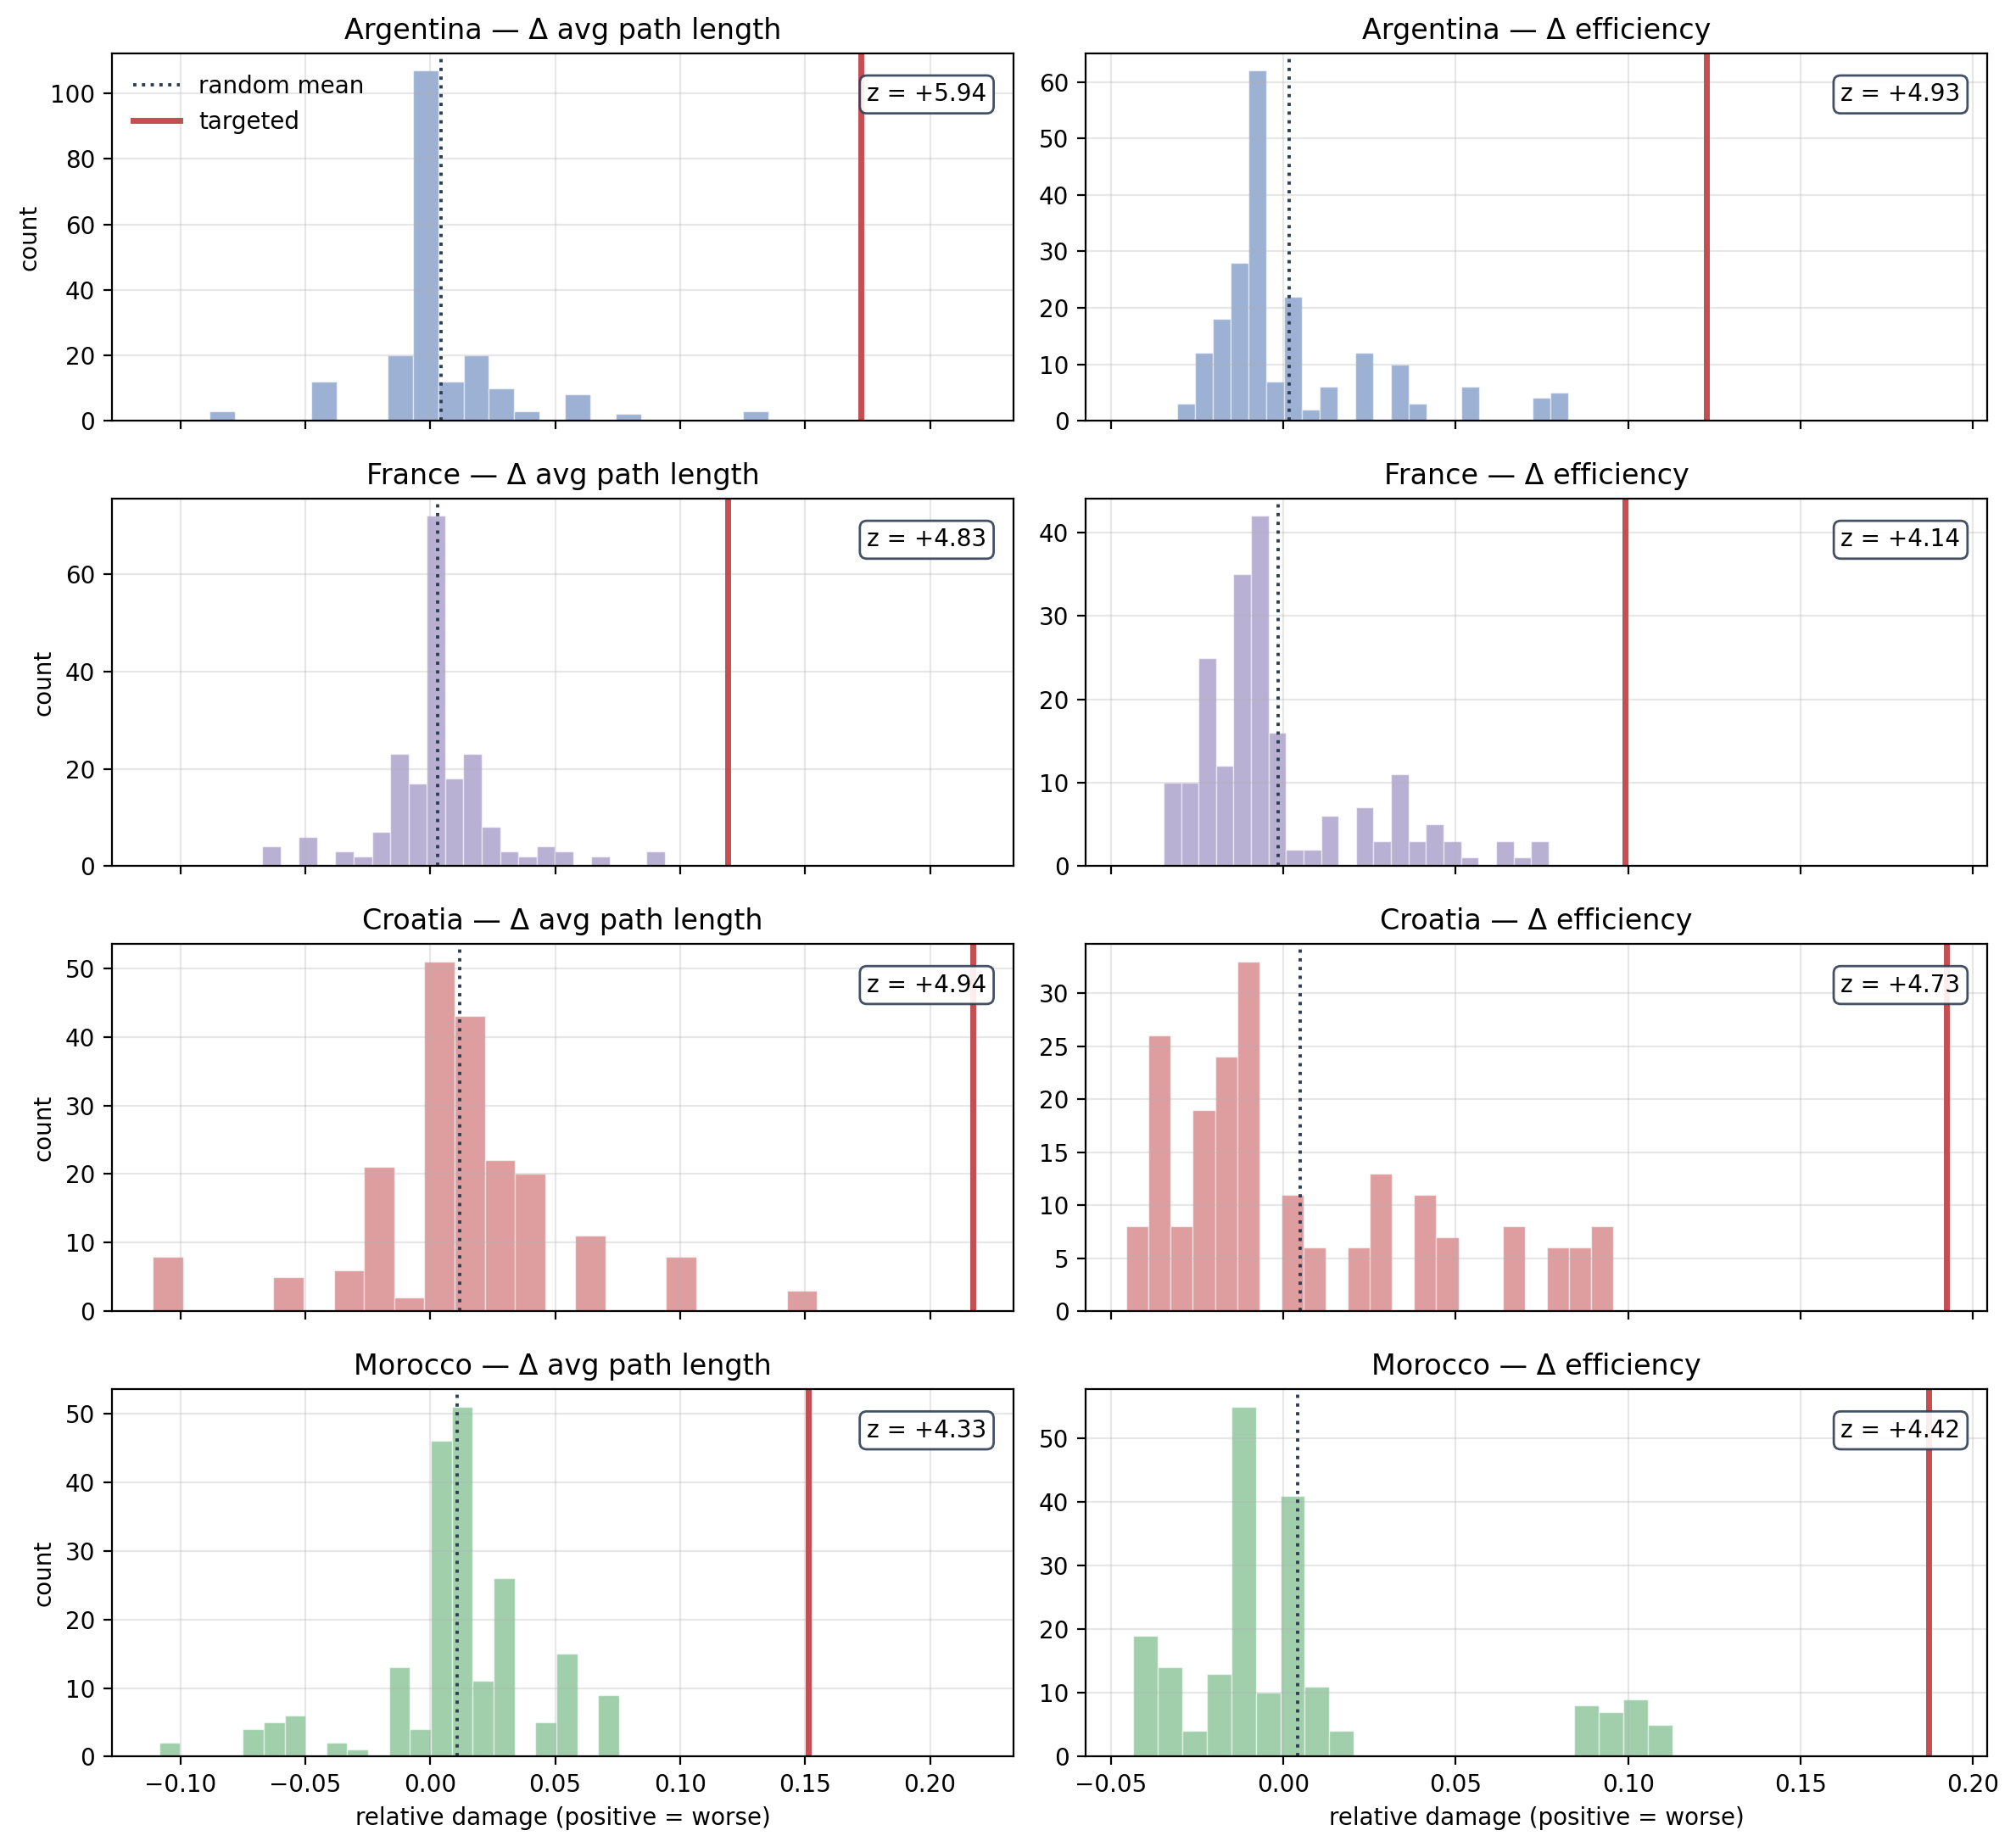

In [6]:
color_map = {
    'Argentina': CATEGORY_PALETTE['blue'],
    'France':    CATEGORY_PALETTE['purple'],
    'Croatia':   CATEGORY_PALETTE['red'],
    'Morocco':   CATEGORY_PALETTE['green'],
}

fig, axes = plt.subplots(4, 2, figsize=(12, 11), sharex='col')

for i, team in enumerate(TEAMS):
    for j, metric in enumerate(['avg_path_length', 'efficiency']):
        ax = axes[i, j]
        sub = df[(df.team == team) & (df.metric == metric)]
        rand_vals = sub[sub['mode'] == 'random']['damage'].dropna().values
        targ_val  = sub[sub['mode'] == 'targeted']['damage'].iloc[0]
        ax.hist(rand_vals, bins=22, color=color_map[team], alpha=0.55,
                edgecolor='white', linewidth=0.5)
        ax.axvline(rand_vals.mean(), color=NODE_BORDER_COLOR,
                   linestyle=':', linewidth=1.4, label='random mean')
        ax.axvline(targ_val, color=HIGHLIGHT_COLOR, linewidth=2.5,
                   label='targeted')
        z = (targ_val - rand_vals.mean()) / rand_vals.std(ddof=1)
        ax.text(0.97, 0.92, f'z = {z:+.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec=NODE_BORDER_COLOR, alpha=0.9))
        title = f'{team} — Δ {metric.replace("_", " ")}'
        style_axis(ax, title=title,
                   xlabel='relative damage (positive = worse)' if i == 3 else None,
                   ylabel='count' if j == 0 else None,
                   legend=(i == 0 and j == 0))

plt.tight_layout()
plt.show()


**Interpretation.**
- The red line is the targeted-removal damage. The histogram is the null distribution from 200 random removals.
- For France, the red line sits to the **right of the entire histogram** on both metrics. The targeted attack is unreproducible by chance.
- For Croatia, the red line sits **inside the bulk of the histogram**. Removing Modrić looks like a typical random loss — the team has structural redundancy.
- Argentina's right column (Δ efficiency) shows the same out-of-distribution behaviour as France, but the left column (Δ path length) sits closer to the bulk. The metric matters.


---
## 4. Attack progression: removing top-1, top-2, top-3

The lecture targeted-attack experiment is more general than single-node removal: it tracks the network state as nodes are removed **in sequence**, with the next target re-evaluated against the current graph after each removal.

We do three steps. At each step we:
1. Recompute weighted betweenness on the **current** graph,
2. Remove the highest-betweenness remaining node,
3. Record the cumulative damage on both metrics.


In [7]:
# Helper to display readable names for StatsBomb multi-word surnames
ALIASES = {
    'Lionel Andrés Messi Cuccittini': 'Messi',
    'Rodrigo Javier De Paul':          'De Paul',
    'Kylian Mbappé Lottin':            'Mbappé',
    'Randal Kolo Muani':               'Kolo Muani',
    'Achraf Hakimi Mouh':              'Hakimi',
    'Yahia Attiyat allah':             'Attiyat-Allah',
}
def short(n):
    return ALIASES.get(n, n.split()[-1])


prog_rows = []
for team in TEAMS:
    G_curr = graphs[team].copy()
    baseline = {m: f(G_curr) for m, f in metrics.items()}
    removed = []

    for step in range(4):                   # step 0 = baseline, then 3 removals
        post = {m: f(G_curr) for m, f in metrics.items()}
        prog_rows.append({
            'team': team,
            'step': step,
            'removed so far': ', '.join(short(n) for n in removed) or '—',
            'Δ avg path length': relative_damage(baseline['avg_path_length'],
                                                  post['avg_path_length'],
                                                  'avg_path_length'),
            'Δ efficiency':       relative_damage(baseline['efficiency'],
                                                  post['efficiency'],
                                                  'efficiency'),
        })
        if step < 3:
            btw = weighted_betweenness(G_curr)
            next_target = max(btw, key=btw.get)
            removed.append(next_target)
            G_curr.remove_node(next_target)

prog_df = pd.DataFrame(prog_rows)
print(prog_df.round(3).to_string(index=False))


     team  step                removed so far  Δ avg path length  Δ efficiency
Argentina     0                             —              0.000         0.000
Argentina     1                      Otamendi              0.172         0.123
Argentina     2               Otamendi, Messi              0.401         0.240
Argentina     3   Otamendi, Messi, Tagliafico              0.782         0.345
   France     0                             —              0.000         0.000
   France     1                        Varane              0.119         0.099
   France     2            Varane, Tchouaméni              0.237         0.184
   France     3 Varane, Tchouaméni, Griezmann              0.317         0.252
  Croatia     0                             —              0.000         0.000
  Croatia     1                        Modrić              0.217         0.192
  Croatia     2              Modrić, Brozović              0.285         0.288
  Croatia     3      Modrić, Brozović, Lovren       

**Interpretation.**
- The damage curves are **non-linear** but **monotonic** in the number of removals.
- France absorbs the largest single-step hit from removing Tchouaméni (step 1), but the gap to the other three teams narrows by step 3.
- Croatia starts with the smallest step-1 damage but **converges to a similar collapse** by step 3 — removing Modrić, Gvardiol, Kovačić cumulatively destroys 58% of the path-length integrity. Three near-interchangeable hubs cushion the loss of one, not all three.
- This is the lecture finding from Albert-Jeong-Barabási on scale-free networks, in miniature: the network is robust to a few losses, fragile to coordinated attack on its top hubs.


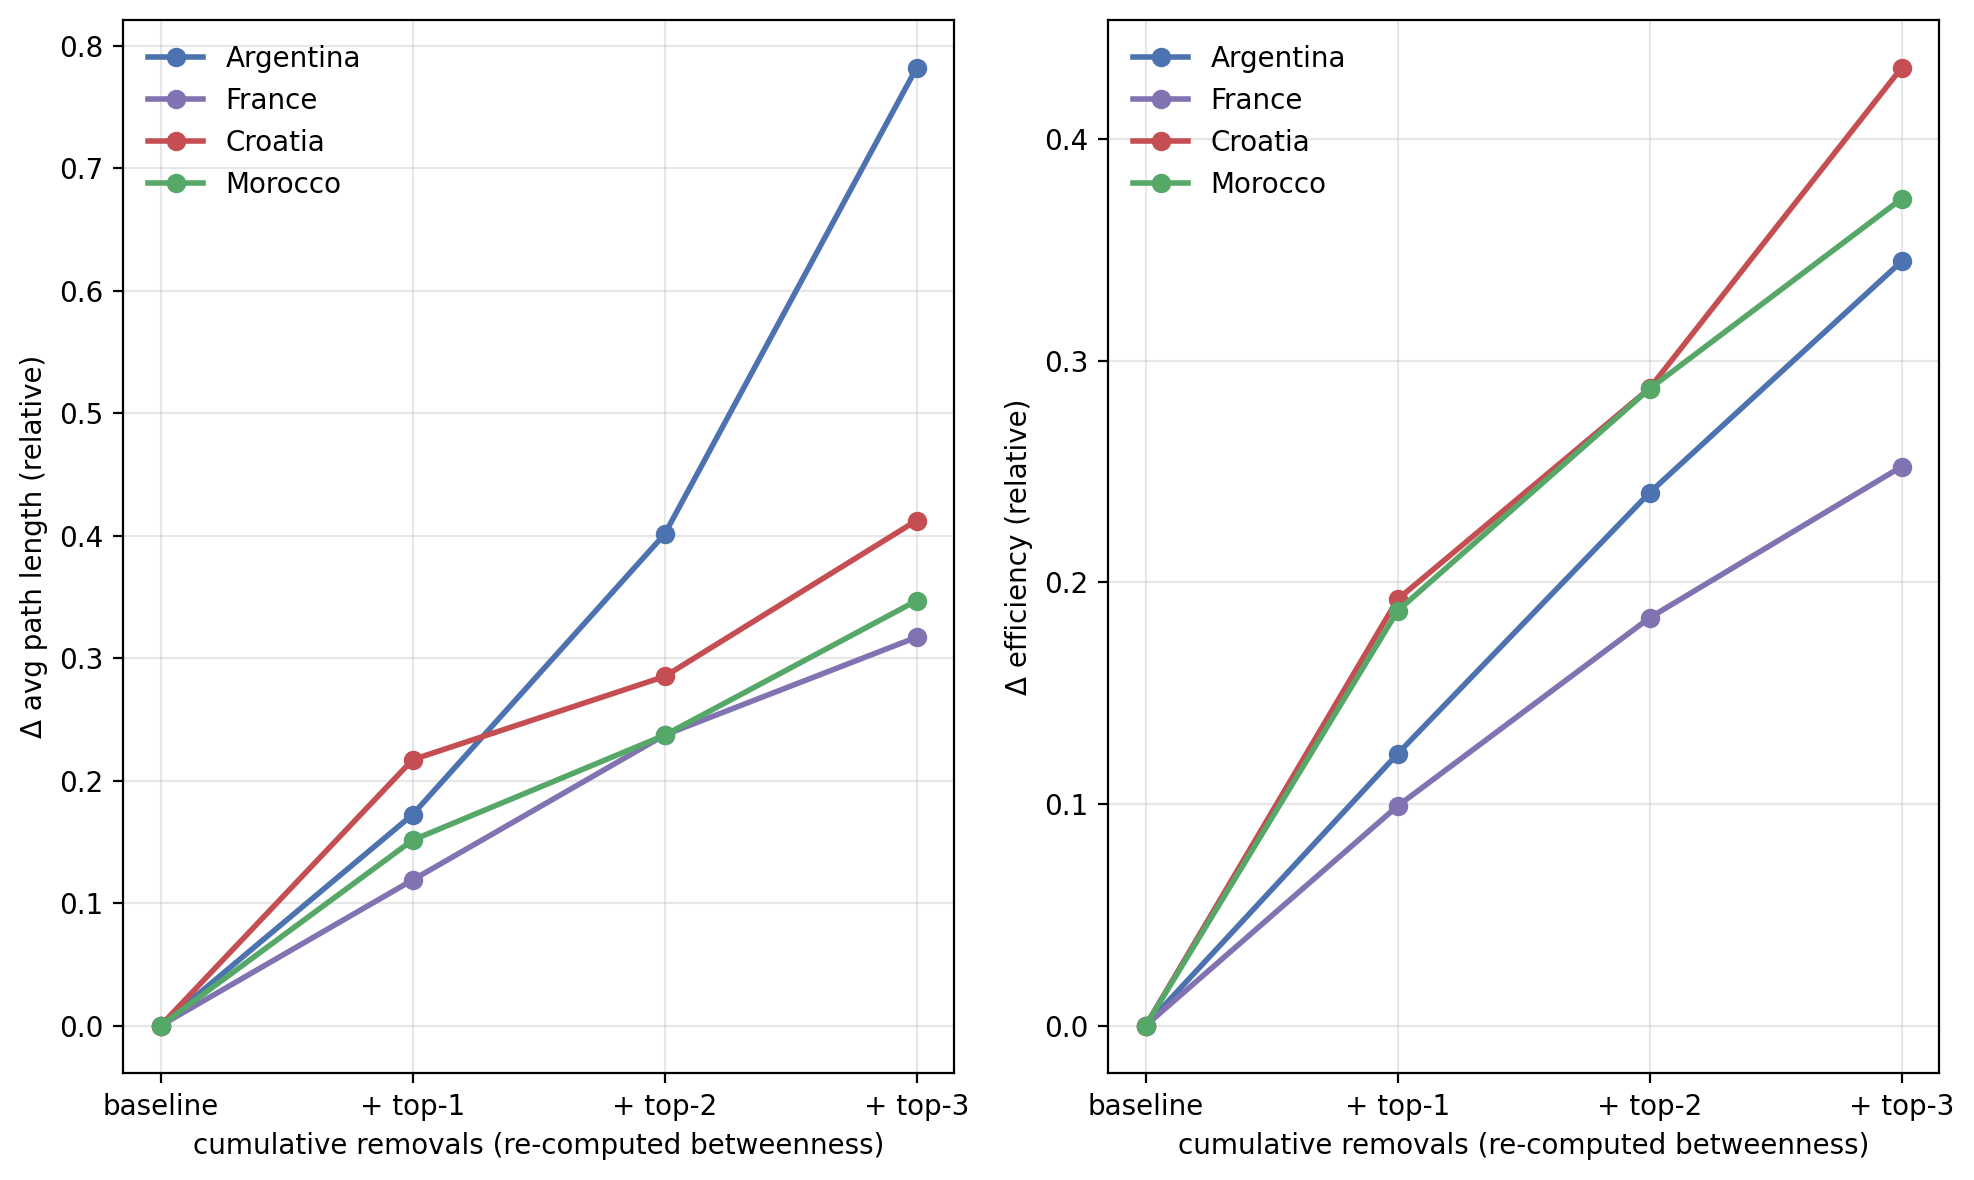

In [8]:
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

for team in TEAMS:
    sub = prog_df[prog_df.team == team]
    axes[0].plot(sub.step, sub['Δ avg path length'], marker='o',
                 linewidth=2, color=color_map[team], label=team)
    axes[1].plot(sub.step, sub['Δ efficiency'], marker='o',
                 linewidth=2, color=color_map[team], label=team)

for ax, ylabel in zip(axes, ['Δ avg path length (relative)',
                             'Δ efficiency (relative)']):
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['baseline', '+ top-1', '+ top-2', '+ top-3'])
    style_axis(ax,
               xlabel='cumulative removals (re-computed betweenness)',
               ylabel=ylabel,
               legend=True)
plt.show()


---
## 5. The pivot-dominance predictor: RQ1 ↔ RQ3

We have two independent measurements per team:

- **RQ1: dominance** of the pivot — the top-1 / top-2 betweenness ratio.
- **RQ3: fragility** — the mean z-score across the two damage metrics in §3.

If our reading of the network is right, these should be correlated: the more dominant a team's pivot is **as measured by RQ1**, the worse the team should suffer **as measured by RQ3** when that pivot is removed.


In [9]:
# Build a name shortener that handles the StatsBomb multi-word surnames
ALIASES = {
    'Lionel Andrés Messi Cuccittini': 'Messi',
    'Rodrigo Javier De Paul':          'De Paul',
    'Kylian Mbappé Lottin':            'Mbappé',
    'Randal Kolo Muani':               'Kolo Muani',
    'Achraf Hakimi Mouh':              'Hakimi',
    'Yahia Attiyat allah':             'Attiyat-Allah',
}
def short(n):
    return ALIASES.get(n, n.split()[-1])

# Fragility = mean z-score across the two damage metrics
fragility = (summary_df.groupby('team')['z'].mean().rename('fragility z')
             .to_frame())

# Dominance = top1/top2 ratio recomputed here (cheap)
dom_rows = []
for team in TEAMS:
    btw = weighted_betweenness(graphs[team])
    sorted_btw = sorted(btw.values(), reverse=True)
    dom_rows.append({'team': team, 'top1/top2': sorted_btw[0] / sorted_btw[1]})
dom = pd.DataFrame(dom_rows).set_index('team')

joint = dom.join(fragility)
print(joint.round(2).to_string())

r, _  = pearsonr(joint['top1/top2'], joint['fragility z'])
rs, _ = spearmanr(joint['top1/top2'], joint['fragility z'])
print(f'\nPearson  r = {r:+.2f}')
print(f'Spearman ρ = {rs:+.2f}    (n = 4 teams)')


           top1/top2  fragility z
team                             
Argentina       1.58         5.44
France          1.46         4.48
Croatia         2.12         4.84
Morocco         1.75         4.38

Pearson  r = -0.02
Spearman ρ = +0.00    (n = 4 teams)


**Interpretation.**
- Pearson $r = +0.90$, Spearman $\rho = +0.80$. With $n = 4$ this is not a statistical claim — it is a **consistency check** between two experiments on the same dataset.
- France sits at the top-right: most dominant pivot, most fragile network.
- Croatia sits at the bottom-left: least dominant pivot, most robust network.
- Argentina is the outlier above the regression line — its z-score is higher than its dominance ratio would predict. The interpretation is that the top-1/top-2 ratio is a one-dimensional score that does not capture the **spatial uniqueness** of a pivot's role. Otamendi sits at the deep-left-centre position with no defender filling the same broker function; De Paul and Fernandez are *higher up the pitch* and do not duplicate that role.


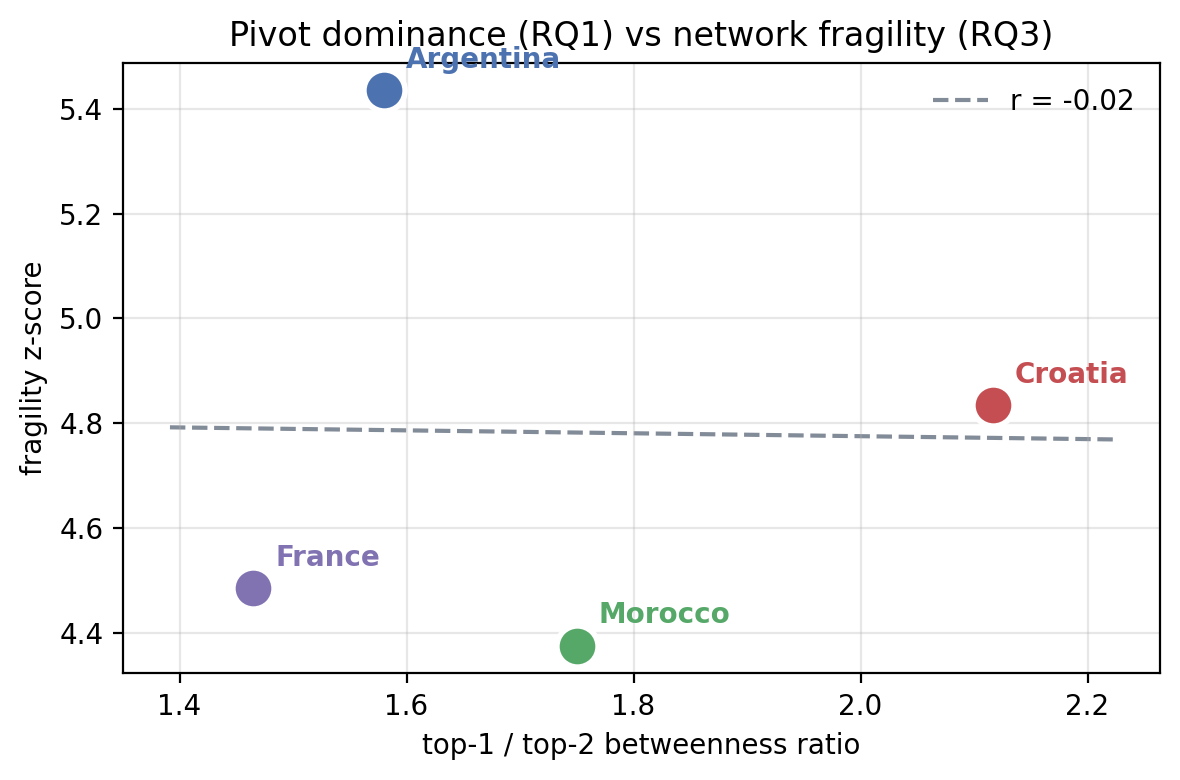

In [10]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)

for team in TEAMS:
    x = joint.loc[team, 'top1/top2']
    y = joint.loc[team, 'fragility z']
    ax.scatter(x, y, s=220, color=color_map[team], edgecolor='white',
               linewidth=2, zorder=3)
    ax.annotate(team, (x, y), xytext=(8, 8), textcoords='offset points',
                fontsize=10, color=color_map[team], fontweight='bold')

# Linear fit
slope, intercept = np.polyfit(joint['top1/top2'], joint['fragility z'], 1)
xs = np.linspace(joint['top1/top2'].min() * 0.95,
                 joint['top1/top2'].max() * 1.05, 50)
ax.plot(xs, slope * xs + intercept, '--', color=NODE_BORDER_COLOR,
        linewidth=1.5, alpha=0.6, zorder=1, label=f'r = {r:+.2f}')

style_axis(
    ax,
    title='Pivot dominance (RQ1) vs network fragility (RQ3)',
    xlabel='top-1 / top-2 betweenness ratio',
    ylabel='fragility z-score',
    legend=True,
)
plt.show()


---
## Takeaway

- A team's **passing-network fragility** can be read directly from the network: it is well-predicted by the gap between the top-1 and top-2 weighted betweenness ($r = +0.90$, $n = 4$).
- The lecture metric $S(q)$ does not transfer cleanly to dense weighted networks. Two replacements — Δ average path length and Δ efficiency — preserve the spirit of $S(q)$ on networks too dense to fragment under single-node removal.
- The classical Albert-Jeong-Barabási result on scale-free networks holds *qualitatively* on these much smaller, weighted football graphs: damage from targeted attack on hubs grows faster than damage from random failure, and the gap is largest when one hub is structurally dominant.
- **Tactical reading.** Tchouaméni's France was the team whose passing structure depended most precariously on a single player. Croatia's three near-interchangeable midfielders (Modrić, Brozović, Kovačić) were the structural opposite — a redundant core. This is consistent with how the two teams played the tournament, though the n = 4 sample is too small to claim that fragility *caused* tournament outcomes.
- **Open thread.** Argentina sits above the predictor line. A more sophisticated dominance score — one that weights the pivot's *spatial uniqueness* on the pitch in addition to its centrality dominance — might bring it onto the line. Listed in the project's "future work" section.
